In [1]:
from field_kit import FourierAnalysis
import matplotlib.pyplot as plt
import yt
import numpy as np

In [2]:
# Load the sloshing dataset
ds = yt.load_sample("GasSloshing/sloshing_nomag2_hdf5_plt_cnt_0150")

/Users/jzuhone/Source/field_kit/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
yt : [INFO     ] 2026-07-26 17:44:01,623 Sample dataset found in '/Users/jzuhone/Data/yt/test_outputs/GasSloshing/sloshing_nomag2_hdf5_plt_cnt_0150'
yt : [INFO     ] 2026-07-26 17:44:02,046 Parameters: current_time              = 1.1835090993823291e+17
yt : [INFO     ] 2026-07-26 17:44:02,046 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2026-07-26 17:44:02,047 Parameters: domain_left_edge          = [-3.70272e+24 -3.70272e+24 -3.70272e+24]
yt : [INFO     ] 2026-07-26 17:44:02,047 Parameters: domain_right_edge         = [3.70272e+24 3.70272e+24 3.70272e+24]
yt : [INFO     ] 2026-07-26 17:44:02,047 Parameters: cosmological_simulation   = 0


yt : [INFO     ] 2026-07-26 17:44:02,383 xlim = -1542838790481162406985728.000000 1542838790481162406985728.000000
yt : [INFO     ] 2026-07-26 17:44:02,383 ylim = -1542838790481162406985728.000000 1542838790481162406985728.000000
yt : [INFO     ] 2026-07-26 17:44:02,384 xlim = -1542838790481162406985728.000000 1542838790481162406985728.000000
yt : [INFO     ] 2026-07-26 17:44:02,384 ylim = -1542838790481162406985728.000000 1542838790481162406985728.000000
yt : [INFO     ] 2026-07-26 17:44:02,386 Making a fixed resolution buffer of (('gas', 'kT')) 800 by 800
yt : [INFO     ] 2026-07-26 17:44:02,470 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800



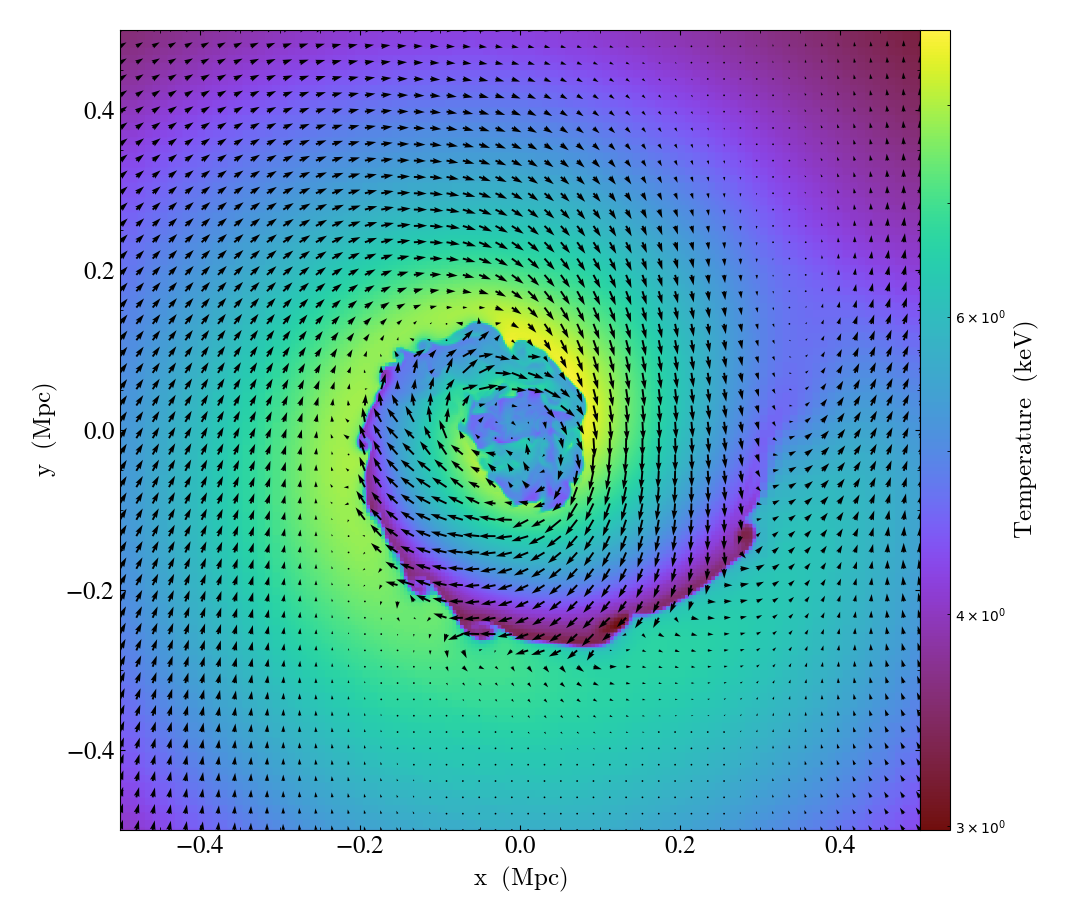
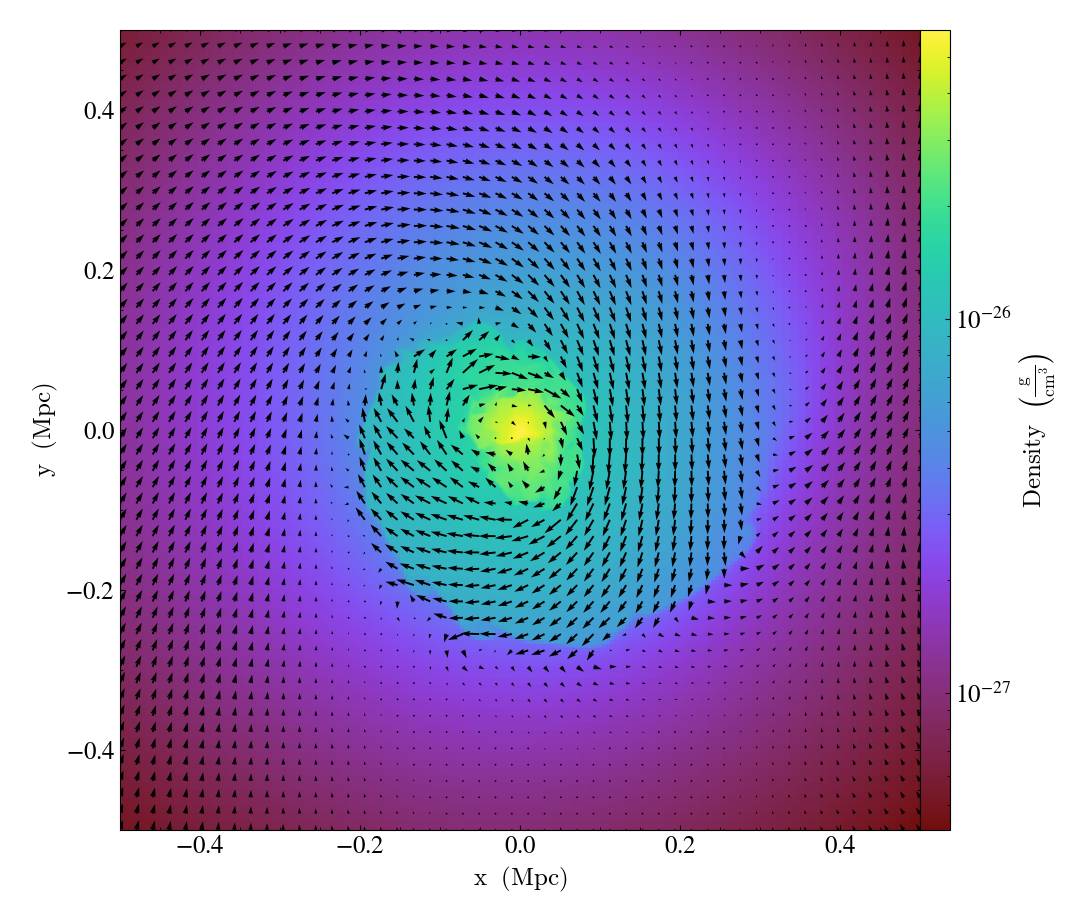

In [3]:
# Plot a slice of the density and temperature to see what it looks like, 
# and annotate with velocity vectors
slc = yt.SlicePlot(
    ds,
    "z",
    [("gas", "density"), ("gas", "kT")],
    width=(1.0, "Mpc"),
)
slc.annotate_velocity()

In [4]:
# This is the width of the grid on a side (here in kpc, but could be anything)
W = ds.arr([400.0] * 3, "kpc")
ddims = [128] * 3

In [5]:
# Use the domain center as the center for the grid
c = ds.domain_center.to("kpc")

In [6]:
# Make a grid object which is uniformly gridded at center c with width W and ddims cells
grid = ds.r[
    c[0] - W[0] / 2 : c[0] + W[0] / 2 : ddims[0] * 1j,
    c[1] - W[1] / 2 : c[1] + W[1] / 2 : ddims[1] * 1j,
    c[2] - W[2] / 2 : c[2] + W[2] / 2 : ddims[2] * 1j,
]

In [7]:
# This is a class I wrote to simplify stuff
fa = FourierAnalysis(W, ddims)

In [8]:
# Get the x-velocity field in km/s on the grid
vx = grid[("gas", "velocity_x")].to_value("km/s")

In [9]:
# here I am applying a hanning window to the data to fix the 
# fact that this is a non-periodic box and avoid aliasing
# we will make a copy to illustrate the difference between 
# windowed and unwindowed data with respect to the power spectrum
vxw = vx.copy()
fa.window_data(vxw)

In [10]:
# Get the power spectrum of each spatial component
nbins = 60  # Number of bins for the power spectrum, it will
# use the min-max wavenumbers as boundaries
k_bins, Pk = fa.make_binned_powerspec(vx, nbins)
kw_bins, Pkw = fa.make_binned_powerspec(vxw, nbins)

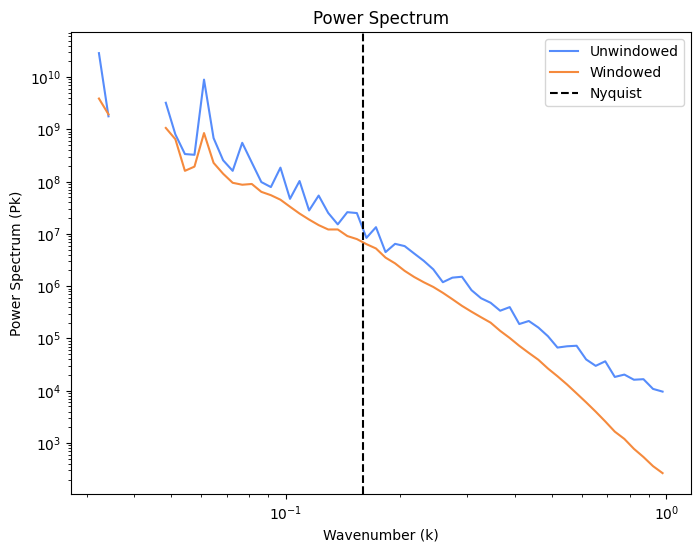

In [11]:
# Now let's plot both the windowed and unwindowed power spectra

# Take the geometric mean of the bins since they are logspaced
k = np.sqrt(k_bins[1:]*k_bins[:-1])
kw = np.sqrt(kw_bins[1:]*kw_bins[:-1])

dx = W[0] / ddims[0]
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.loglog(k, Pk, label="Unwindowed")
ax.loglog(kw, Pkw, label="Windowed")
ax.set_xlabel("Wavenumber (k)")
ax.set_ylabel("Power Spectrum (Pk)")
ax.set_title("Power Spectrum")
ax.axvline(1.0 / (2.0 * dx), color="k", ls="--", label="Nyquist")
ax.legend()